In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path ='/content/drive/MyDrive/heart.csv'
df = pd.read_csv(file_path)
(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


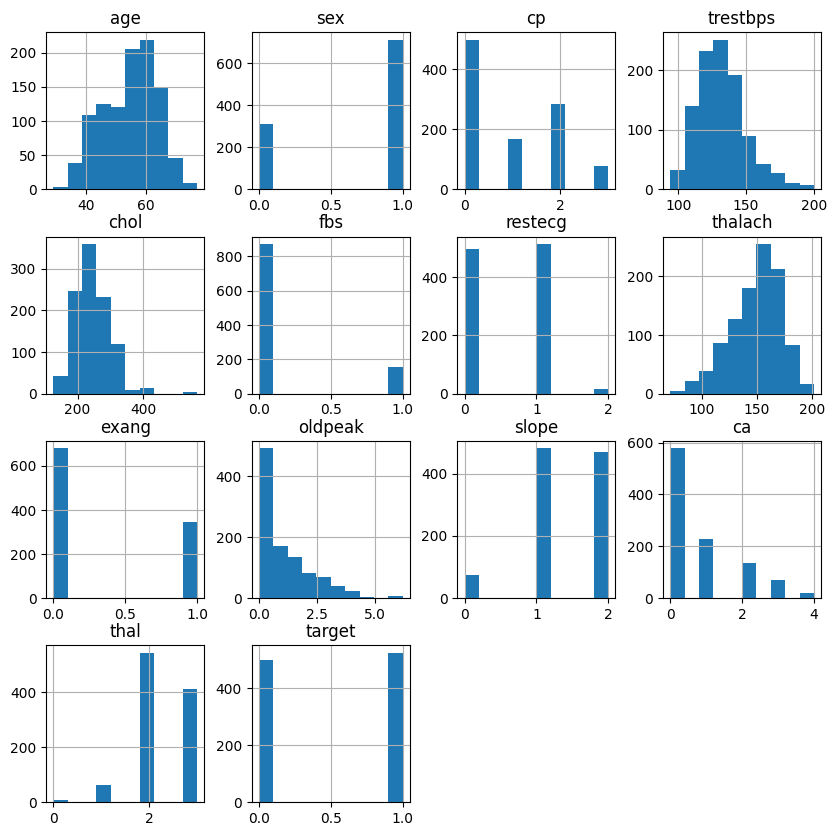

In [ ]:
df.hist(figsize=(10,10))
plt.show()

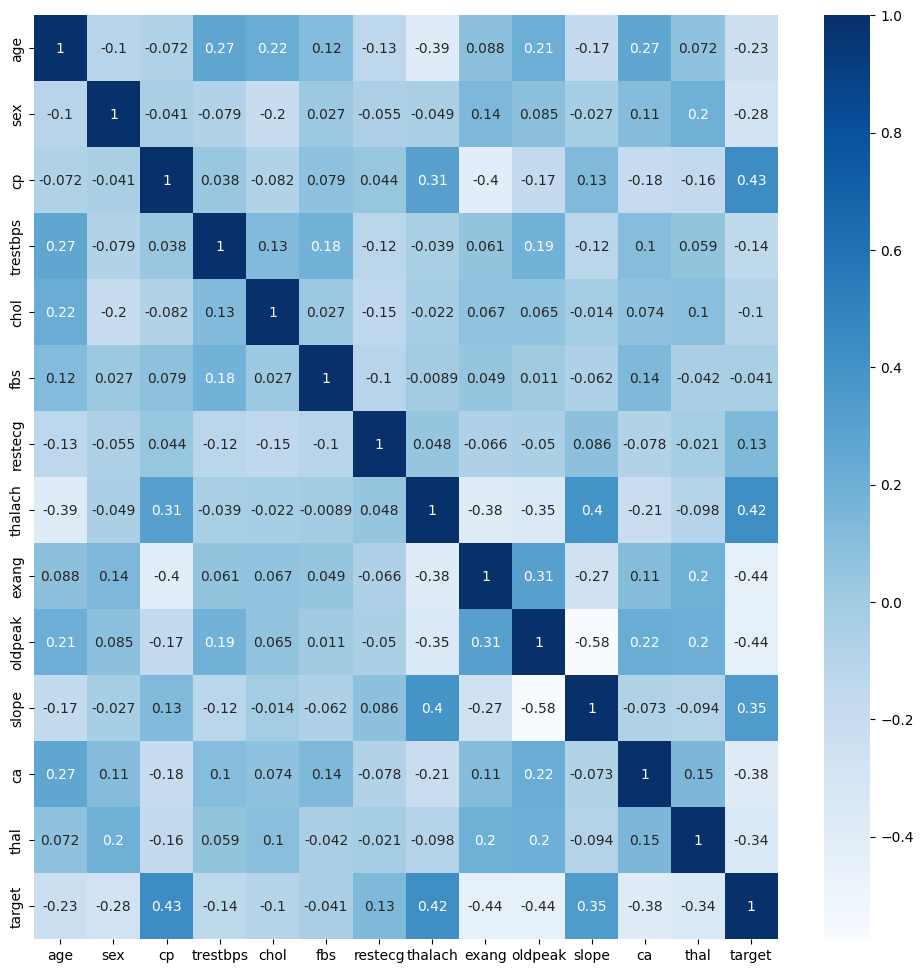

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(12,12)) # this line is used to expand the size of the CM
sns.heatmap(corr_matrix, annot=True, cmap='Blues') # we can set any colors using cmap
plt.show()

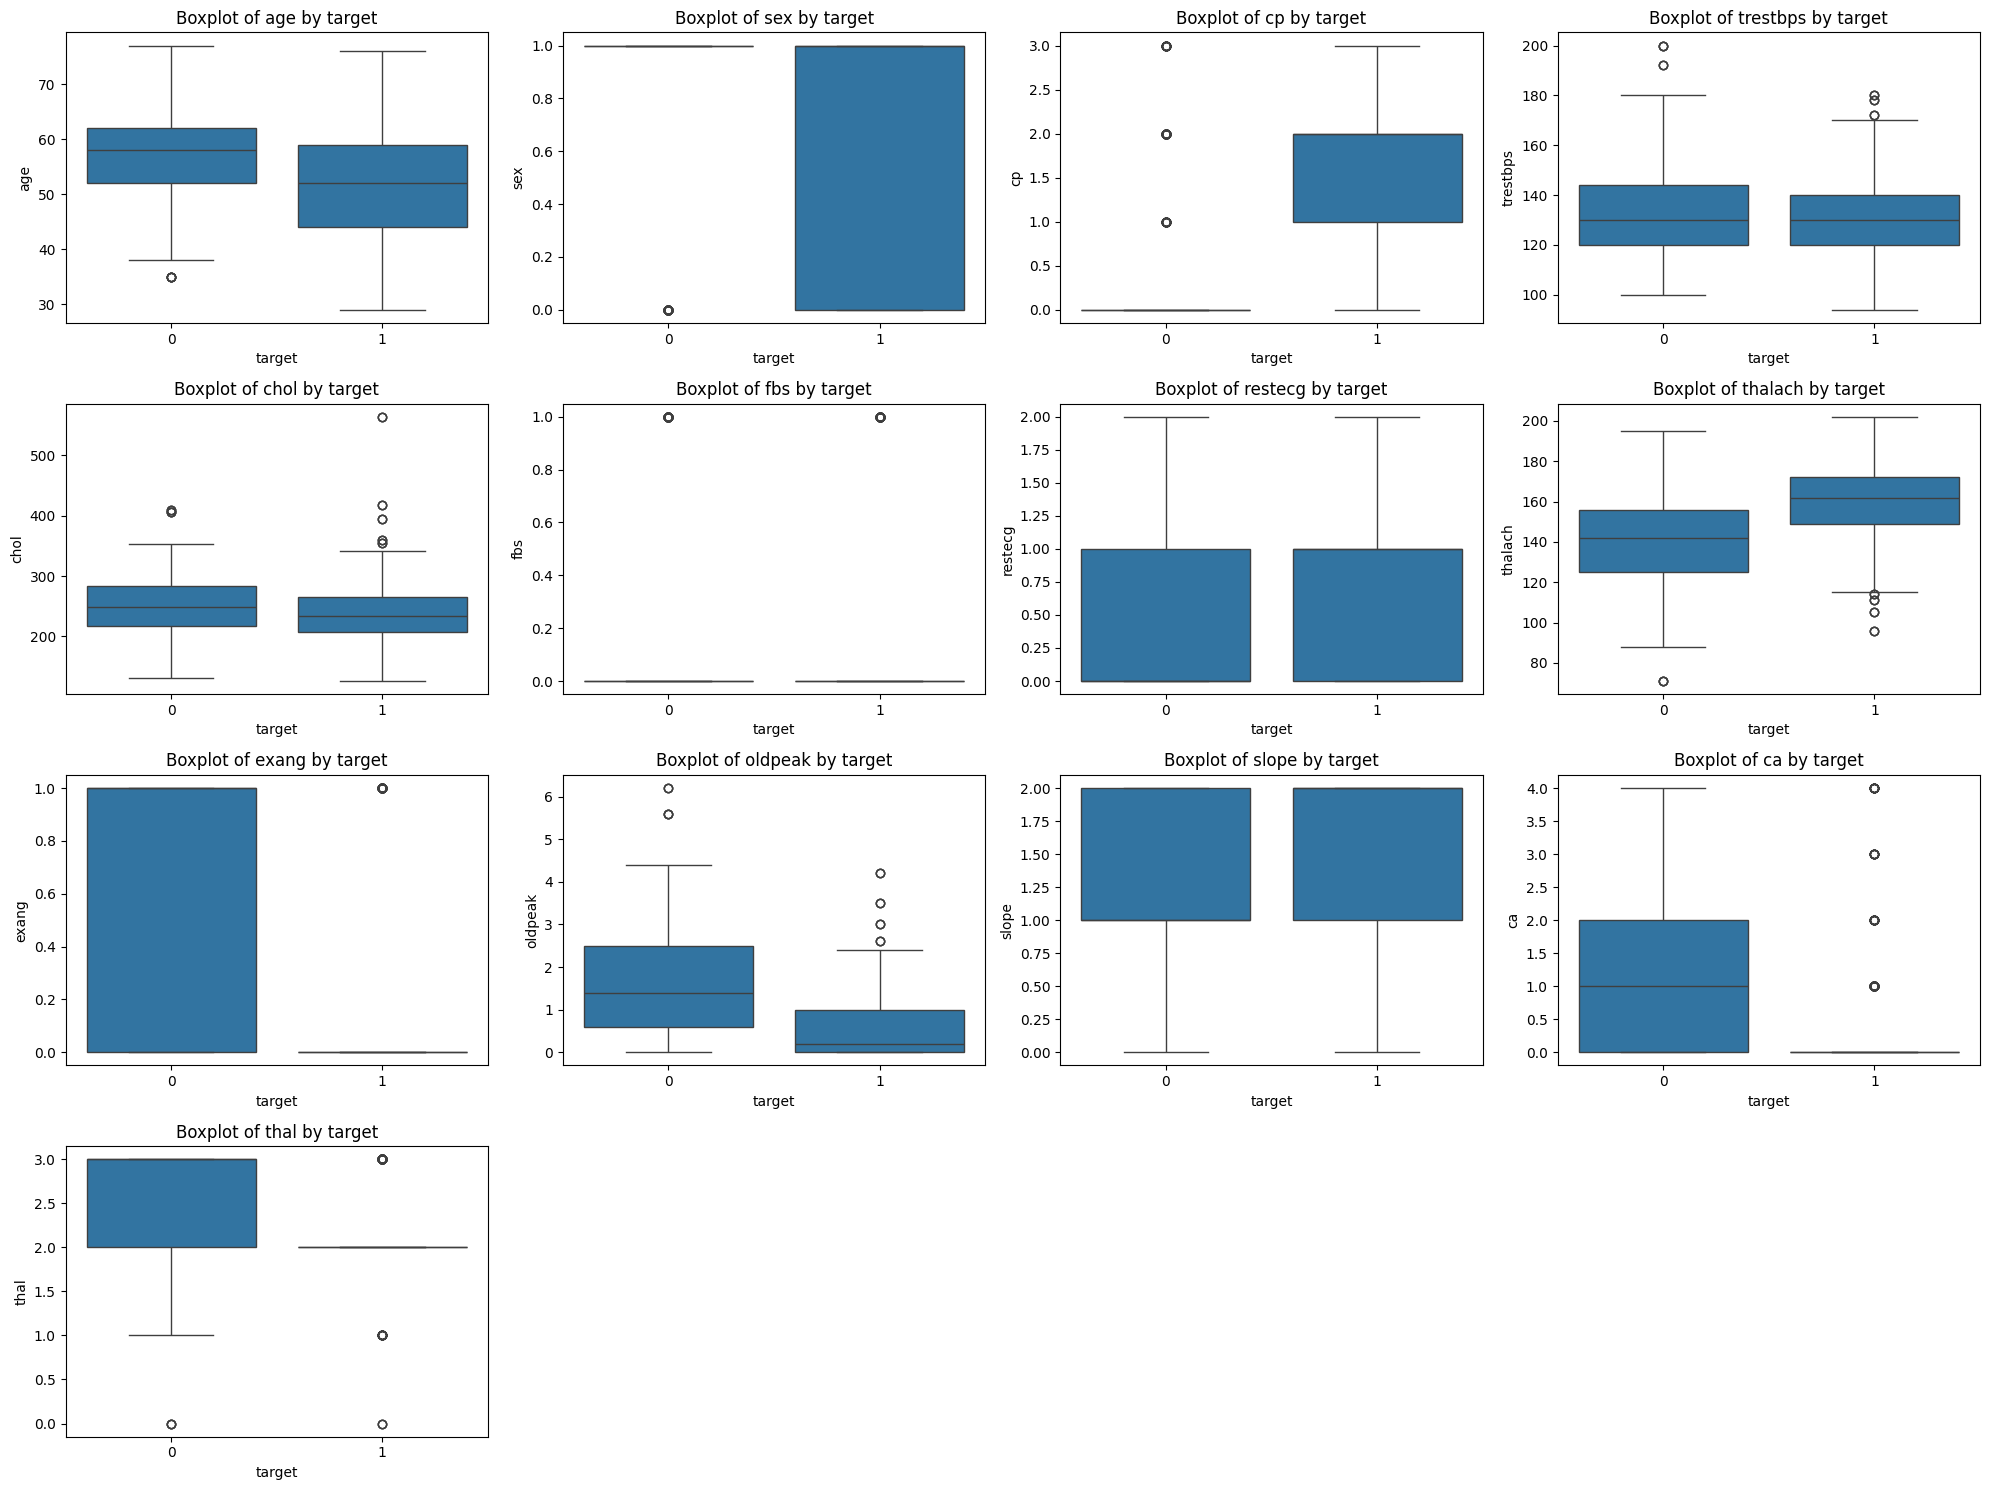

In [ ]:
features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
plt.figure(figsize=(20,15))

for i, features in enumerate(features, 1):
  plt.subplot(4, 4, i)
  sns.boxplot(x='target', y= features, data=df)
  plt.title(f'Boxplot of {features} by target')


plt.tight_layout()
plt.show()

In [ ]:
x = df.drop('target',axis=1)
y = df['target']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Logistic Regression Accuracy:")
accuracy_score(y_test,y_pred)

Logistic Regression Accuracy:


0.7804878048780488

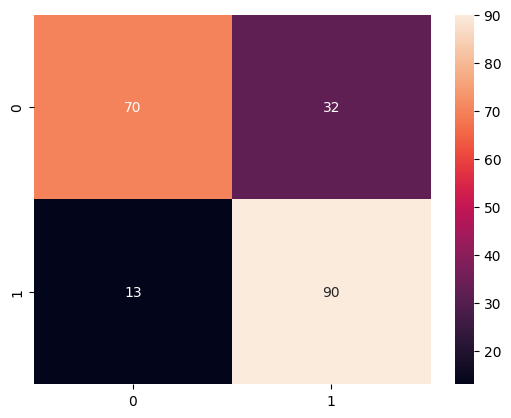

In [ ]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
def predict_target():
  features = []
  for col in x.columns:
    val = float(input(f"Enter {col}: "))
    features.append(val)

  features = np. array(features).reshape(1, -1)
  features = scaler.transform(features)

  prediction = lr.predict(features)
  if(prediction[0] ==1):
    print("Heart Disease Is Found")
  else:
    print("Heart Disease Is Not Found")

In [ ]:
predict_target()

Enter age: 16
Enter sex: 1
Enter cp: 3
Enter trestbps: 6
Enter chol: 5
Enter fbs: 2.2
Enter restecg: 3
Enter thalach: 4.2
Enter exang: 3.2
Enter oldpeak: 6
Enter slope: 4
Enter ca: 1
Enter thal: 2
Heart Disease Is Not Found


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
xgb_model = XGBClassifier(random_state=42,eval_metric='logloss')
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score
print("XG boost Accuracy:")
accuracy_score(y_test,y_pred)

XG boost Accuracy:


0.7804878048780488

In [ ]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
print("Decision tree Accuracy:")
accuracy_score(y_test,y_pred)

Decision tree Accuracy:


0.7804878048780488

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
print("Random Forest  Accuracy:")
accuracy_score(y_test,y_pred)

Random Forest  Accuracy:


0.7804878048780488

In [ ]:
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
print("KNN Accuracy:")
accuracy_score(y_test,y_pred)

KNN Accuracy:


0.7804878048780488

In [ ]:
svm=SVC()
svm.fit(x_train,y_train)

SVC()

In [ ]:
from sklearn.metrics import accuracy_score
print("SVC Accuracy:")
accuracy_score(y_test,y_pred)

SVC Accuracy:


0.7804878048780488

<Figure size 1000x1000 with 0 Axes>

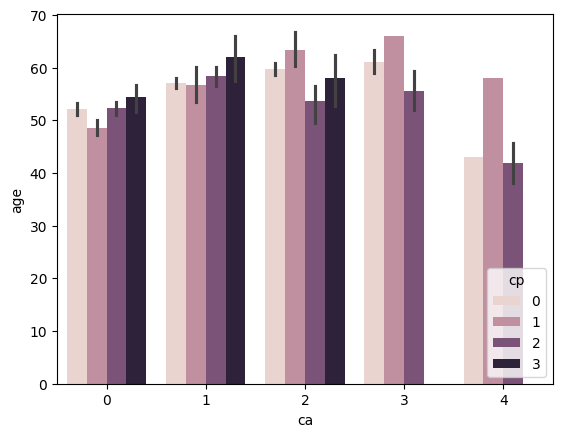

<Figure size 1000x1000 with 0 Axes>

In [ ]:
sns.barplot(data=df,x="ca",y="age",hue="cp")
plt.figure(figsize=(10,10))

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(x_train,y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
y_pred = dtree.predict(x_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rfg = RandomForestRegressor(random_state=0)
rfg.fit(x_train, y_train)

RandomForestRegressor(random_state=0)

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# Initialize and train the AdaBoost Regressor model
abr = AdaBoostRegressor(random_state=0)
abr.fit(x_train, y_train)

AdaBoostRegressor(random_state=0)